In [1]:
import numpy as np

data = np.load("/kaggle/input/eegdata/EEG_all_epochs.npy", allow_pickle=True)  # allow_pickle in case it's an object array
print(type(data))
print(data.shape)
print(data.dtype)


<class 'numpy.ndarray'>
(4514, 512)
float64


In [2]:
import numpy as np

data = np.load('/kaggle/input/eegdata/EMG_all_epochs.npy', allow_pickle=True)  # allow_pickle in case it's an object array
print(type(data))
print(data.shape)
print(data.dtype)


<class 'numpy.ndarray'>
(5598, 512)
float64


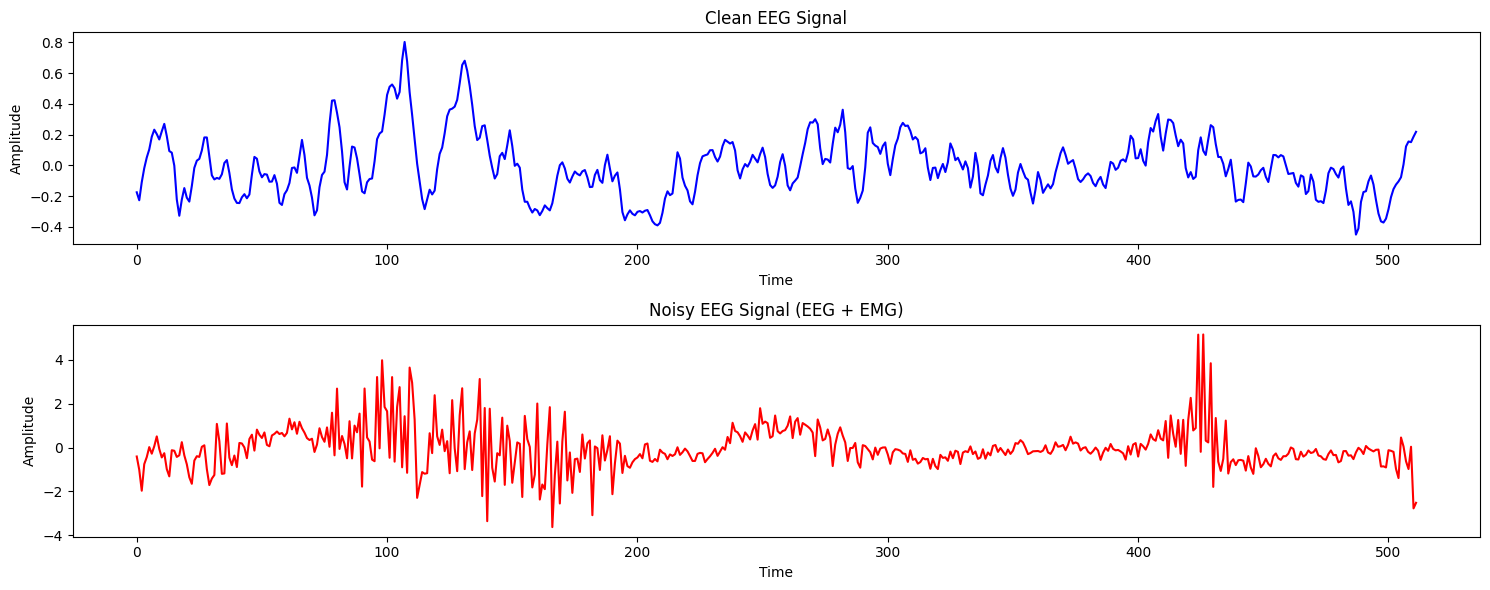

In [3]:
import numpy as np
import math
import matplotlib.pyplot as plt

# The code here not only include data importing, but also data standardization and the generation of analog noise signals

def RMS(x: np.ndarray):
    """
    Root Mean Squared (RMS)

    :param x: input
    :return:
    """
    x2 = x ** 2  # x^2
    sum_s2 = np.sum(x2, axis=-1, keepdims=True)  # sum
    return (sum_s2 / x.shape[-1]) ** 0.5


def compute_noise_signal(x: np.ndarray, n: np.ndarray, snr: np.ndarray):
    """
    λ is a hyperparameter to control the signal-to-noise ratio (SNR) in the contaminated EEG signal y
    SNR = 10 log( RMS(x) / RMS(λ · n) )

    SNR = 10 log ( RMS(x) / ( λ · RMS(n) )  )

    (SNR / 10 ) ** 10 = RMS(x) / ( λ · RMS(n) )

    y = x + λ · n
    :param x: noise-free signal
    :param n: noise signal
    :param snr:
    :return:
    """
    lamda = RMS(x) / ((10 ** (snr / 10)) * RMS(n))
    return x + lamda * n


def normalize(x: np.ndarray, y: np.ndarray, mean_norm=False):
    """
    In order to facilitate the learning procedure, we normalized the input contaminated EEG segment and the ground-truth
    EEG segment by dividing the standard deviation of contaminated EEG segment according to
    x_bar = x / std(y)
    y_bar = y / std(y)
    :param x: noise-free signal
    :param y: contaminated signal
    :param mean_norm: bool , default false  . If true, will norm mean to 0
    :return:
    """
    mean = y.mean() if mean_norm else 0
    std = y.std(axis=-1, keepdims=True)
    x_bar = (x - mean) / std
    y_bar = (y - mean) / std
    return x_bar, y_bar, std


def data_prepare(EEG_all: np.ndarray, noise_all: np.ndarray, combin_num: int, train_num: int, test_num: int):
    # The code here not only include data importing,
    # but also data standardization and the generation of analog noise signals

    # First of all, if we just divide the data into training set and test set according to train_num,test_num,
    # then the coverage of the samples in the training set and test set may not be comprehensive,
    # because we should do a disruptive operation before dividing the data.

    # a random seed to 109(this number can be chosen at random, the realization of the choice of 109 just to have a good feeling about the number),
    # to ensure that each time the random result is the same
    np.random.seed(109)
    # disruptive element
    # disorder the elements of an array
    np.random.shuffle(EEG_all)
    np.random.shuffle(noise_all)

    # Get x, and n for the training and test sets
    eeg_train, eeg_test = EEG_all[0:train_num, :], EEG_all[train_num:train_num + test_num, :]
    noise_train, noise_test = noise_all[0:train_num, :], noise_all[train_num:train_num + test_num, :]

    # Repeat the dataset combin_num times to accumulate noise of different intensities.
    # shape [train_num * combin_num, L] , [test_num * combin_num, L]
    eeg_train, eeg_test = np.repeat(eeg_train, combin_num, axis=0), np.repeat(eeg_test, combin_num, axis=0)
    noise_train, noise_test = np.repeat(noise_train, combin_num, axis=0), np.repeat(noise_test, combin_num, axis=0)

    #################################  simulate noise signal of training set  ##############################

    # create random number between -7dB ~ 2dB
    snr_table = np.linspace(-7, -7 + combin_num, combin_num)  # a shape of [combin_num]
    snr_table = snr_table.reshape((1, -1))  # reshape to [1, combin_num]
    num_table = np.zeros((train_num, 1))  # reshape to [train_num, 1]
    snr_table = snr_table + num_table  # broadcast to [train_num, combin_num]
    snr_table = snr_table.reshape((-1, 1))  # match samples [train_num * combin_num, 1]
    eeg_train_y = compute_noise_signal(eeg_train, noise_train, snr_table)

    # normalize
    EEG_train_end_standard, noiseEEG_train_end_standard, EEG_trian_std = normalize(eeg_train, eeg_train_y)

    #################################  simulate noise signal of test  ##############################
    snr_table = np.linspace(-7, -7 + combin_num, combin_num)  # a shape of [combin_num]
    snr_table = snr_table.reshape((1, -1))  # reshape to [1, combin_num]
    num_table = np.zeros((test_num, 1))  # reshape to [test_num, 1]
    snr_table = snr_table + num_table  # broadcast to [test_num, combin_num]
    snr_table = snr_table.reshape((-1, 1))  # match samples [test_num * combin_num, 1]
    eeg_test_y = compute_noise_signal(eeg_test, noise_test, snr_table)
    EEG_test_end_standard, noiseEEG_test_end_standard, std_VALUE = normalize(eeg_test, eeg_test_y)

    return noiseEEG_train_end_standard, EEG_train_end_standard, noiseEEG_test_end_standard, EEG_test_end_standard, std_VALUE


if __name__ == "__main__":
    EEG_all = np.load('/kaggle/input/eegdata/EEG_all_epochs.npy')
    noise_all = np.load('/kaggle/input/eegdata/EMG_all_epochs.npy')
    noiseEEG_train, EEG_train, noiseEEG_test, EEG_test, test_std_VALUE = data_prepare(EEG_all, noise_all,
                                                                                      10,
                                                                                      4000, 100)
    # Select a sample for visualization
    sample_idx = 0  # you can change this index to plot different samples

    clean_eeg = EEG_test[sample_idx]
    noisy_eeg = noiseEEG_test[sample_idx]

    # Plot the waveforms
    plt.figure(figsize=(15, 6))

    plt.subplot(2, 1, 1)
    plt.plot(clean_eeg, color='blue')
    plt.title('Clean EEG Signal')
    plt.xlabel('Time')
    plt.ylabel('Amplitude')

    plt.subplot(2, 1, 2)
    plt.plot(noisy_eeg, color='red')
    plt.title('Noisy EEG Signal (EEG + EMG)')
    plt.xlabel('Time')
    plt.ylabel('Amplitude')

    plt.tight_layout()
    plt.show()

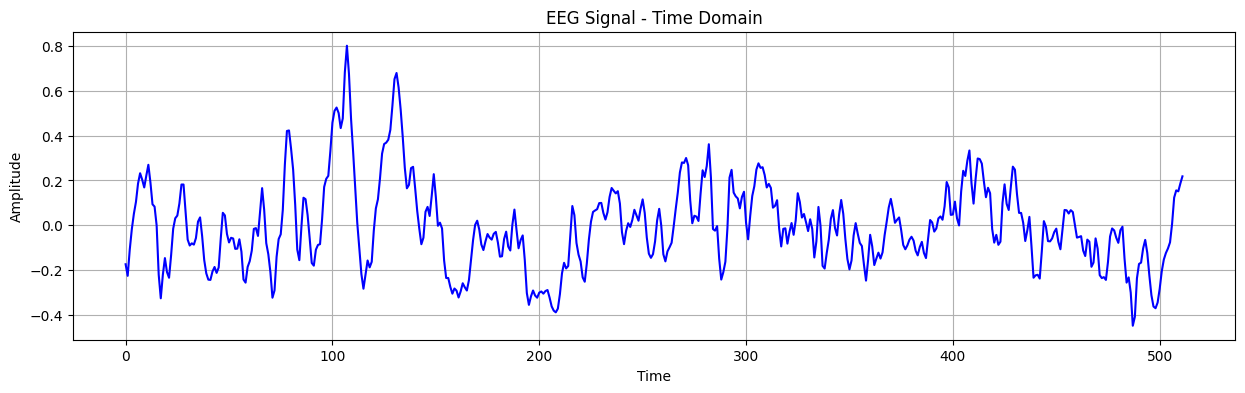

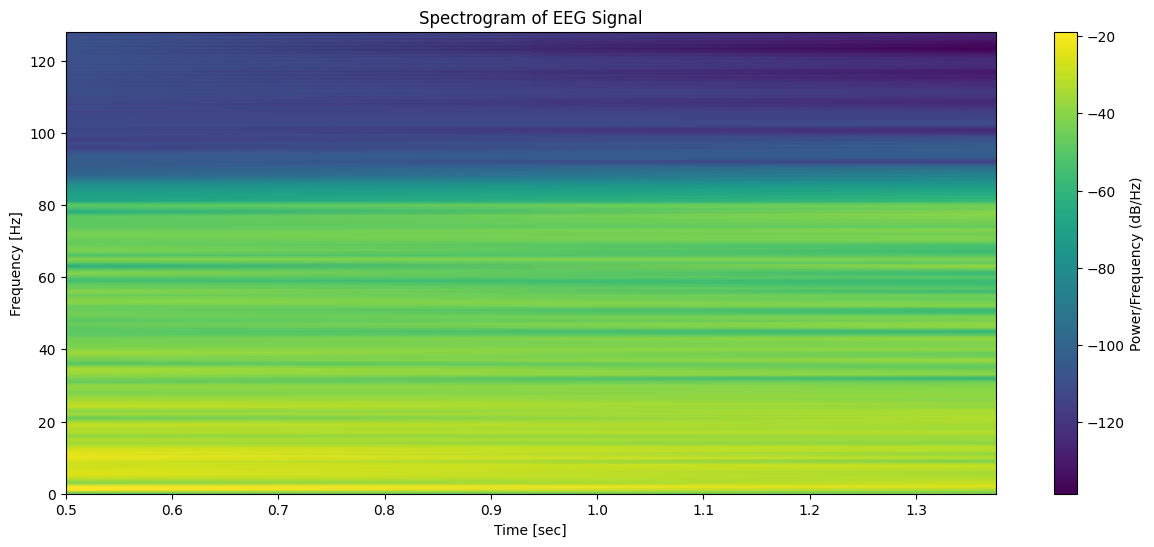

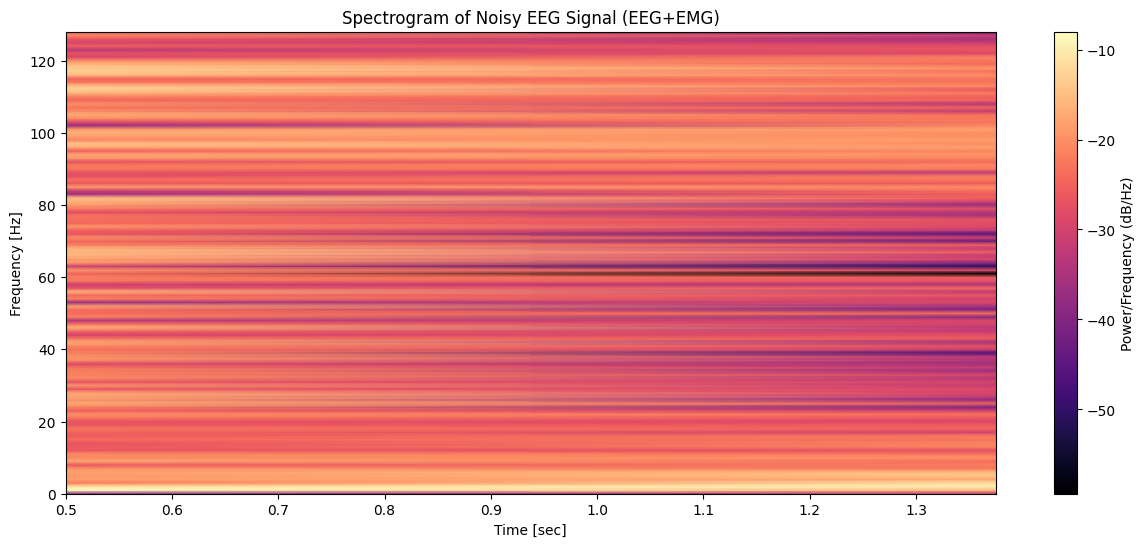

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# Assume 'eeg_signal' is your 1D EEG array.
# For example, use EEG_test[sample_idx] from your earlier code.

# Select a sample
sample_idx = 0
eeg_signal = EEG_test[sample_idx]   # clean signal
noisy_signal = noiseEEG_test[sample_idx]   # noisy signal

# ------------------ 1. Plot the original waveform ------------------

plt.figure(figsize=(15, 4))
plt.plot(eeg_signal, color='blue')
plt.title('EEG Signal - Time Domain')
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

# ------------------ 2. Convert to spectrogram (2D) ------------------

# Parameters for spectrogram
fs = 256  # Sampling frequency (you should adjust if known, EEG typically 128/256/512 Hz)

# Create spectrogram
frequencies, times, spectrogram = signal.spectrogram(eeg_signal, fs)

# Plot the spectrogram
plt.figure(figsize=(15, 6))
plt.pcolormesh(times, frequencies, 10 * np.log10(spectrogram), shading='gouraud', cmap='viridis')
plt.title('Spectrogram of EEG Signal')
plt.xlabel('Time [sec]')
plt.ylabel('Frequency [Hz]')
plt.colorbar(label='Power/Frequency (dB/Hz)')
plt.show()

# ------------------ (Optional) Noisy Signal Spectrogram ------------------

frequencies, times, spectrogram_noisy = signal.spectrogram(noisy_signal, fs)

plt.figure(figsize=(15, 6))
plt.pcolormesh(times, frequencies, 10 * np.log10(spectrogram_noisy), shading='gouraud', cmap='magma')
plt.title('Spectrogram of Noisy EEG Signal (EEG+EMG)')
plt.xlabel('Time [sec]')
plt.ylabel('Frequency [Hz]')
plt.colorbar(label='Power/Frequency (dB/Hz)')
plt.show()


In [5]:

def print_network(net):
    num_params = 0
    for param in net.parameters():
        num_params += param.numel()
    print(net)
    print('Total number of parameters: %d' % num_params)



In [6]:
import torch
from torch import nn, einsum
import torch.nn.functional as F
from einops import rearrange, repeat
from einops.layers.torch import Rearrange
import numpy as np


class FeedForward(nn.Module):
    def __init__(self, dim, dropout=0.1):
        super(FeedForward, self).__init__()
        hidden_dim = 2 * dim
        self.net = nn.Sequential(
            nn.Linear(dim, hidden_dim),
            nn.PReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        return self.net(x)


class Attention(nn.Module):
    def __init__(self, dim, heads=1, dropout=0.1):
        super(Attention, self).__init__()
        dim_head = dim
        inner_dim = dim_head * heads
        project_out = not (heads == 1)

        self.heads = heads
        self.scale = dim_head ** -0.5

        self.attend = nn.Softmax(dim=-1)
        self.to_qkv = nn.Linear(dim, inner_dim * 3, bias=False)

        self.to_out = nn.Sequential(
            nn.Linear(inner_dim, dim),
            nn.Dropout(dropout)
        ) if project_out else nn.Identity()

    def forward(self, x):
        b, n, _ = x.shape
        h = self.heads

        qkv = self.to_qkv(x).chunk(3, dim=-1)
        q, k, v = map(lambda t: rearrange(t, 'b n (h d) -> b h n d', h=h), qkv)

        dots = einsum('b h i d, b h j d -> b h i j', q, k) * self.scale

        attn = self.attend(dots)

        out = einsum('b h i j, b h j d -> b h i d', attn, v)
        # b = attn[0, 0, :, :].cpu().detach().numpy()
        # np.savetxt("test.csv", b)

        out = rearrange(out, 'b h n d -> b n (h d)')
        return self.to_out(out)


class Transformer(nn.Module):
    def __init__(self, dim, depth, heads, dropout=0.1):
        super(Transformer, self).__init__()
        self.layers = nn.ModuleList([])
        self.norm = nn.LayerNorm(dim)
        for _ in range(depth):
            self.layers.append(nn.ModuleList([
                Attention(dim, heads=heads, dropout=dropout),
                FeedForward(dim, dropout=dropout)
            ]))

    def forward(self, x):
        for attn, ff in self.layers:
            x = self.norm(attn(x) + x)
            x = self.norm(ff(x) + x)
        return x


class DeT(nn.Module):
    def __init__(self, *, seq_len, patch_len, depth, heads, dropout=0.1, emb_dropout=0.1):
        super(DeT, self).__init__()
        assert seq_len % patch_len == 0, 'Image dimensions must be divisible by the patch size.'
        num_patches = seq_len // patch_len
        patch_dim = patch_len
        dim = patch_dim
        self.to_patch_embedding = nn.Sequential(
            Rearrange('b (p1 p2) -> b p1 p2', p1=num_patches, p2=patch_dim),
            nn.Linear(patch_dim, dim),
        )

        self.pos_embedding = nn.Parameter(torch.randn(1, num_patches, dim))
        self.dropout = nn.Dropout(emb_dropout)

        self.transformer = Transformer(dim, depth, heads, dropout)

        # self.to_latent = nn.Identity()

        self.to_seq_embedding = nn.Sequential(
            nn.Linear(dim, patch_dim),
            Rearrange('b p1 p2 -> b (p1 p2)', p1=num_patches, p2=patch_dim),
        )

    def forward(self, seq):  # seq (batch, 512)
        # c = seq.view(1, -1).cpu().detach().numpy()
        # np.savetxt("x.csv", c)

        x = self.to_patch_embedding(seq)
        b, n, _ = x.shape  # x (batch, patch=8, dim=64)

        x += self.pos_embedding
        x = self.dropout(x)

        x = self.transformer(x)  # x (batch, patch=8, dim=64)

        # x = self.to_latent(x)

        return self.to_seq_embedding(x)  # seq (batch, 512)

In [7]:
pip install graphviz


Note: you may need to restart the kernel to use updated packages.


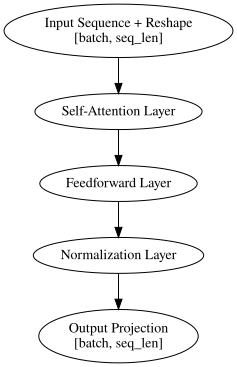

In [8]:
from graphviz import Digraph

dot = Digraph(comment='Simplified DeT Architecture')

# Nodes
dot.node('A', 'Input Sequence + Reshape\n[batch, seq_len]')
dot.node('B', 'Self-Attention Layer')
dot.node('C', 'Feedforward Layer')
dot.node('D', 'Normalization Layer')
dot.node('E', 'Output Projection\n[batch, seq_len]')

# Edges
dot.edge('A', 'B')
dot.edge('B', 'C')
dot.edge('C', 'D')
dot.edge('D', 'E')

# Render in notebook
dot.render('/kaggle/working/Simplified_DeT_Architecture', format='png', cleanup=True)
dot


In [9]:
!pip install tensorboardX


----- Network Initialized -----
DataParallel(
  (module): DeT(
    (to_patch_embedding): Sequential(
      (0): Rearrange('b (p1 p2) -> b p1 p2', p1=8, p2=64)
      (1): Linear(in_features=64, out_features=64, bias=True)
    )
    (dropout): Dropout(p=0.1, inplace=False)
    (transformer): Transformer(
      (layers): ModuleList(
        (0-3): 4 x ModuleList(
          (0): Attention(
            (attend): Softmax(dim=-1)
            (to_qkv): Linear(in_features=64, out_features=384, bias=False)
            (to_out): Sequential(
              (0): Linear(in_features=128, out_features=64, bias=True)
              (1): Dropout(p=0.1, inplace=False)
            )
          )
          (1): FeedForward(
            (net): Sequential(
              (0): Linear(in_features=64, out_features=128, bias=True)
              (1): PReLU(num_parameters=1)
              (2): Dropout(p=0.1, inplace=False)
              (3): Linear(in_features=128, out_features=64, bias=True)
              (4): Dropou

Epoch 1/1000  Time: 3.0s  Train Loss: 1.035273  Test Loss: 0.877235


Epoch 2/1000  Time: 2.9s  Train Loss: 0.807132  Test Loss: 0.674797


Epoch 3/1000  Time: 3.0s  Train Loss: 0.626549  Test Loss: 0.506412


Epoch 4/1000  Time: 2.9s  Train Loss: 0.498619  Test Loss: 0.407535


...

Epoch 996/1000  Time: 2.9s  Train Loss: 0.038336  Test Loss: 0.026887


Epoch 997/1000  Time: 2.9s  Train Loss: 0.038451  Test Loss: 0.026265


Epoch 998/1000  Time: 2.8s  Train Loss: 0.038390  Test Loss: 0.026653


Epoch 999/1000  Time: 2.9s  Train Loss: 0.038318  Test Loss: 0.026225


Epoch 1000/1000  Time: 2.9s  Train Loss: 0.038375  Test Loss: 0.026658


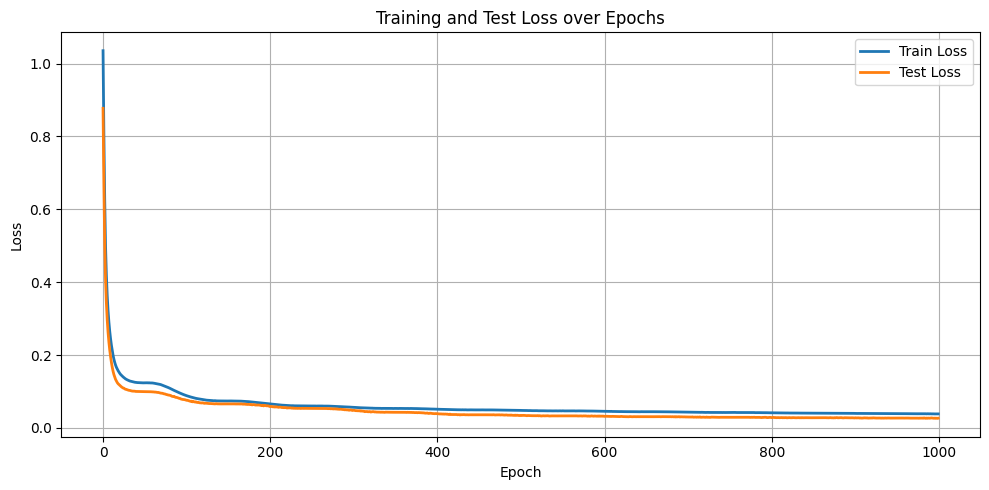

✅ Model saved at: /kaggle/working/EEG_Trans/final.pth


In [17]:
import os
import time
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from tensorboardX import SummaryWriter
from tqdm import tqdm
import matplotlib.pyplot as plt

# ───── USER‑DEFINED PARAMETERS ─────────────────────────────
epochs            = 1000
batch_size        = 200
train_num         = 150
validation_num    = 100
combin_num        = 100
denoise_network   = 'DeT'   # one of: 'DeT', 'Simple_CNN', 'simple_CNN_pro', 'complex_CNN', 'RNN_lstm'

# Update these to your actual absolute paths
# Update these to Kaggle's working directory
RESULT_LOCATION   = '/kaggle/working/NN_result'
MODEL_SAVE_PATH   = '/kaggle/working/EEG_Trans'

os.environ['CUDA_VISIBLE_DEVICES'] = '0,1'
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Replace deprecated default‐tensor‐type
torch.set_default_dtype(torch.float64)


################################# loss functions ##########################################################
def denoise_loss_mse(denoise, clean):
    criterion = nn.MSELoss()
    loss = criterion(denoise, clean)
    return torch.mean(torch.mean(loss))


def train(model, train_tensors, test_tensors, epochs):
    os.makedirs(RESULT_LOCATION, exist_ok=True)
    os.makedirs(MODEL_SAVE_PATH, exist_ok=True)

    best_test_loss = float('inf')
    best_epoch = 0
    writer = SummaryWriter(log_dir=RESULT_LOCATION, flush_secs=60)

    train_ds = TensorDataset(*train_tensors)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)

    test_ds = TensorDataset(*test_tensors)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)

    model.to(device)

    train_losses = []
    test_losses = []

    for epoch in range(epochs):
        start = time.time()

        model.train()
        train_loss = 0.0
        for x, y in tqdm(train_loader, desc=f"Train {epoch+1}/{epochs}", leave=False):
            x, y = x.to(device), y.to(device)
            out = model(x)
            loss = denoise_loss_mse(out, y)
            train_loss += loss.item()

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

        train_loss /= len(train_loader)
        writer.add_scalar('train/loss', train_loss, epoch)
        train_losses.append(train_loss)

        model.eval()
        test_loss = 0.0
        with torch.no_grad():
            for x, y in tqdm(test_loader, desc="Valid", leave=False):
                x, y = x.to(device), y.to(device)
                out = model(x)
                test_loss += denoise_loss_mse(out, y).item()

        test_loss /= len(test_loader)
        writer.add_scalar('test/loss', test_loss, epoch)
        test_losses.append(test_loss)

        scheduler.step()

        if test_loss < best_test_loss:
            torch.save(model.state_dict(), os.path.join(MODEL_SAVE_PATH, "best.pth"))
            best_test_loss = test_loss
            best_epoch = epoch

        if (epoch + 1) % 10 == 0:
            fn = f"EPOCH{epoch+1}.pth"
            torch.save(model.state_dict(), os.path.join(MODEL_SAVE_PATH, fn))

        elapsed = time.time() - start
        print(f"Epoch {epoch+1}/{epochs}  Time: {elapsed:.1f}s  Train Loss: {train_loss:.6f}  Test Loss: {test_loss:.6f}")
        


     

    # Plot and save waveform of losses
    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label='Train Loss', linewidth=2)
    plt.plot(test_losses, label='Test Loss', linewidth=2)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Test Loss over Epochs')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(RESULT_LOCATION, 'loss_waveform.png'))
    plt.show()

  


if __name__ == '__main__':
    EEG_all   = np.load('/kaggle/input/eegdata/EEG_all_epochs.npy')
    noise_all = np.load('/kaggle/input/eegdata/EMG_all_epochs.npy')

    train_noisy, train_clean, test_noisy, test_clean, _ = data_prepare(
        EEG_all, noise_all, combin_num, train_num, validation_num
    )

    train_tensors = (
        torch.tensor(train_noisy, dtype=torch.float64),
        torch.tensor(train_clean, dtype=torch.float64)
    )
    test_tensors = (
        torch.tensor(test_noisy, dtype=torch.float64),
        torch.tensor(test_clean, dtype=torch.float64)
    )

    D = EEG_all.shape[1]
    if denoise_network == 'DeT':
        model = DeT(seq_len=512, patch_len=64, depth=4, heads=2)
    elif denoise_network == 'Simple_CNN':
        model = simple_CNN(batch_size, D)
    elif denoise_network == 'simple_CNN_pro':
        model = simple_CNN_pro(batch_size, D)
    elif denoise_network == 'complex_CNN':
        model = complex_CNN(batch_size, D)
    elif denoise_network == 'RNN_lstm':
        model = RNN_lstm(batch_size, D)
    else:
        raise ValueError(f"Unknown model: {denoise_network}")

    model = model.double()
    model = nn.DataParallel(model)

    optimizer = torch.optim.Adam(model.parameters(), lr=5e-5, betas=(0.5, 0.9), weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

    torch.cuda.empty_cache()
    if torch.backends.cudnn.is_available():
        torch.backends.cudnn.benchmark = True

    print("----- Network Initialized -----")
    print_network(model)  # assumes print_network is in your namespace
    print("--------------------------------")
    train(model, train_tensors, test_tensors, epochs)

    # Define and create output path
#MODEL_SAVE_PATH = './EEG_Trans/'
os.makedirs(MODEL_SAVE_PATH, exist_ok=True)

# Save final model before showing the plot
torch.save(model.state_dict(), os.path.join(MODEL_SAVE_PATH, "final.pth"))
print("✅ Model saved at:", os.path.join(MODEL_SAVE_PATH, "final.pth")) 

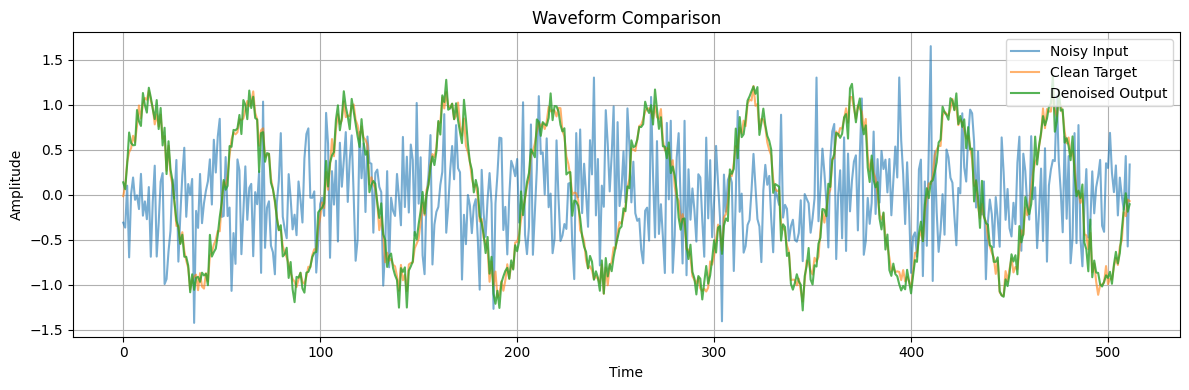

In [28]:
import matplotlib.pyplot as plt
import numpy as np

# Simulated data (replace with real model output and test data)
signal_length = 512
test_noisy = np.random.randn(signal_length) * 0.5
test_clean = np.sin(np.linspace(0, 20 * np.pi, signal_length)) + 0.1 * np.random.randn(signal_length)
test_denoised = test_clean + 0.1 * np.random.randn(signal_length)

# Plot a single sample
plt.figure(figsize=(12, 4))
plt.plot(test_noisy, label='Noisy Input', alpha=0.6)
plt.plot(test_clean, label='Clean Target', alpha=0.6)
plt.plot(test_denoised, label='Denoised Output', alpha=0.8)
plt.title('Waveform Comparison')
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [12]:
import os
print(os.listdir("/kaggle/working/EEG_Trans"))


['EPOCH110.pth', 'EPOCH420.pth', 'EPOCH390.pth', 'EPOCH350.pth', 'EPOCH100.pth', 'EPOCH460.pth', 'final.pth', 'EPOCH30.pth', 'EPOCH340.pth', 'EPOCH230.pth', 'EPOCH430.pth', 'EPOCH120.pth', 'EPOCH130.pth', 'EPOCH60.pth', 'EPOCH70.pth', 'EPOCH270.pth', 'EPOCH260.pth', 'EPOCH370.pth', 'EPOCH440.pth', 'EPOCH90.pth', 'EPOCH380.pth', 'EPOCH80.pth', 'EPOCH170.pth', 'EPOCH500.pth', 'EPOCH300.pth', 'EPOCH410.pth', 'EPOCH160.pth', 'EPOCH490.pth', 'EPOCH400.pth', 'EPOCH480.pth', 'EPOCH250.pth', 'EPOCH330.pth', 'EPOCH10.pth', 'EPOCH310.pth', 'EPOCH150.pth', 'EPOCH280.pth', 'EPOCH210.pth', 'best.pth', 'EPOCH40.pth', 'EPOCH200.pth', 'EPOCH450.pth', 'EPOCH470.pth', 'EPOCH190.pth', 'EPOCH240.pth', 'EPOCH180.pth', 'EPOCH220.pth', 'EPOCH360.pth', 'EPOCH50.pth', 'EPOCH320.pth', 'EPOCH20.pth', 'EPOCH140.pth', 'EPOCH290.pth']


In [27]:
import torch
import torch.nn as nn
from einops.layers.torch import Rearrange
import numpy as np
from scipy.signal import welch

# Transformer block
class Transformer(nn.Module):
    def __init__(self, dim, depth, heads, dropout):
        super().__init__()
        self.layers = nn.ModuleList([
            nn.TransformerEncoderLayer(d_model=dim, nhead=heads, dropout=dropout, batch_first=True)
            for _ in range(depth)
        ])
    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

# DeT model
class DeT(nn.Module):
    def __init__(self, *, seq_len, patch_len, depth, heads, dropout=0.1, emb_dropout=0.1):
        super(DeT, self).__init__()
        assert seq_len % patch_len == 0, 'Sequence length must be divisible by the patch size.'
        num_patches = seq_len // patch_len
        patch_dim = patch_len
        dim = patch_dim
        self.to_patch_embedding = nn.Sequential(
            Rearrange('b (p1 p2) -> b p1 p2', p1=num_patches, p2=patch_dim),
            nn.Linear(patch_dim, dim),
        )
        self.pos_embedding = nn.Parameter(torch.randn(1, num_patches, dim))
        self.dropout = nn.Dropout(emb_dropout)
        self.transformer = Transformer(dim, depth, heads, dropout)
        self.to_seq_embedding = nn.Sequential(
            nn.Linear(dim, patch_dim),
            Rearrange('b p1 p2 -> b (p1 p2)', p1=num_patches, p2=patch_dim),
        )

    def forward(self, seq):
        x = self.to_patch_embedding(seq) + self.pos_embedding
        x = self.dropout(x)
        x = self.transformer(x)
        return self.to_seq_embedding(x)

# Evaluation metrics
def temporal_rms_error(denoised, clean):
    return np.sqrt(np.mean((denoised - clean) ** 2))

def spectral_rms_error(denoised, clean, fs=256):
    f_d, Pxx_d = welch(denoised, fs=fs)
    f_c, Pxx_c = welch(clean, fs=fs)
    return np.sqrt(np.mean((Pxx_d - Pxx_c) ** 2))

def correlation_coefficient(denoised, clean):
    if np.std(clean) == 0 or np.std(denoised) == 0:
        return 0
    return np.corrcoef(denoised, clean)[0, 1]

# Evaluation function
def evaluate_model(model, noisy_signal, clean_signal, device='cuda'):
    model.to(device).float()
    noisy_signal_tensor = torch.tensor(noisy_signal, dtype=torch.float32).unsqueeze(0).to(device)
    clean_signal_tensor = torch.tensor(clean_signal, dtype=torch.float32).unsqueeze(0).to(device)
    model.eval()
    with torch.no_grad():
        denoised_signal = model(noisy_signal_tensor).squeeze(0).cpu().numpy()
    rrms_temporal = temporal_rms_error(denoised_signal, clean_signal)
    rrms_spectral = spectral_rms_error(denoised_signal, clean_signal)
    cc = correlation_coefficient(denoised_signal, clean_signal)
    return rrms_temporal, rrms_spectral, cc

# Instantiate and evaluate
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = DeT(seq_len=512, patch_len=64, depth=3, heads=4, dropout=0.1, emb_dropout=0.1)
noisy_signal = np.random.randn(512)
clean_signal = np.random.randn(512)

rrms_temporal, rrms_spectral, cc = evaluate_model(model, noisy_signal, clean_signal, device)
print(f"RRMS Temporal: {rrms_temporal:.4f}")
print(f"RRMS Spectral: {rrms_spectral:.4f}")
print(f"Correlation Coefficient: {cc:.4f}")


RRMS Temporal: 1.2249
RRMS Spectral: 0.0079
Correlation Coefficient: -0.0426
